# Import Libraries

In [1]:
import datetime
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from suds.client import Client
from Add_In_Queries import *

In [15]:
first_date = get_positions("PF86307", "28/08/2025")
first_date = first_date.set_index("instNum")
second_date = get_positions("PF86307", "31/01/2025")
second_date = second_date.set_index("instNum")

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Fixed Income/Add_In_Queries.py:239: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.DataFrame(data,columns=columns).replace('soapenc:string',0)


In [3]:
issuers_first_date = get_instrument_data(list(first_date.index), "31/01/2025")
issuers_second_date = get_instrument_data(list(second_date.index), "14/05/2025")

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Fixed Income/Add_In_Queries.py:275: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.DataFrame(data,columns=columns).replace('soapenc:string',0)


In [4]:
issuers_first_date_code = set(issuers_first_date["instIssuerCode"])
issuers_second_date_code = set(issuers_second_date["instIssuerCode"])

In [6]:
intersection = issuers_second_date_code.intersection(issuers_first_date_code)

In [7]:
ratings = pd.DataFrame(index=list(intersection))
ratings["Name"] = issuers_second_date.set_index("instIssuerCode")["instIssuerName"]
ratings["January"] = issuers_first_date.set_index("instIssuerCode")["issuerRatingAMedLT"]
ratings["May"] = issuers_second_date.set_index("instIssuerCode")["issuerRatingAMedLT"]

In [8]:
ratings.index.name = "Issuer Code"
ratings.iloc[np.where(ratings["January"] != ratings["May"])]

,Name,January,May
Issuer Code,,,
10707,VOLKSWAGEN INTL FIN NV,A-,BBB+
2133,WOLTERS KLUWER NV,BBB+,A-
122870,ORSTED AS,BBB+,BBB
146670,SANOFI SA,A+,AA-
159663,STELLANTIS NV,BBB+,BBB
174324,AROUNDTOWN SA,BBB+,BBB
153992,GRAND CITY PROPERTIES SA,BBB+,BBB


In [17]:
first_date['positionMktPositionValueEUR'].astype(float).sum()

np.float64(130534033.42747259)

In [19]:
perf=get_perf('PF86307','20250101','20250801',type_code='DecalogCodePtf')

/home/jovyan/notebooks/alto_studio/Risk/Analysis/Portfolio Review/Fixed Income/Add_In_Queries.py:44: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data["valuationDate"] = pd.to_datetime(


<Axes: xlabel='valuationDate'>

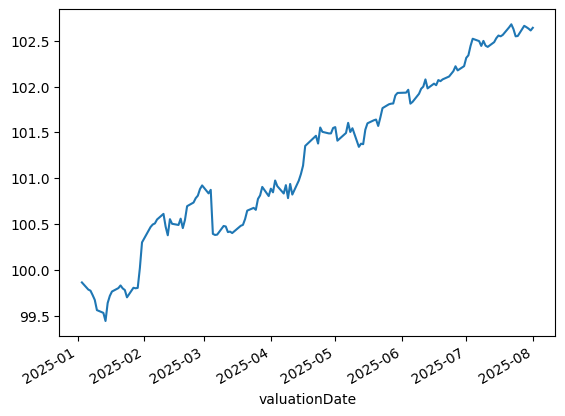

In [29]:
((1+perf['grossperf'].iloc[:]/100).cumprod()*100).plot()